# Ariel data challenge model evaluation

## 1. Notebooks set up

In [ ]:
# Standard library imports
from pathlib import Path

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from matplotlib.ticker import FormatStrFormatter

# Project imports
from ariel_data_preprocessing.data_generator_functions import make_training_datasets

2025-09-23 15:19:55.723276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758640795.928683      26 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758640795.995365      26 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 2. Initialize data generators

In [2]:
sample_size = 372
n_samples = 10

_, _, evaluation_dataset = make_training_datasets(
    data_file='/kaggle/input/ariel-training-data/train.h5',
    sample_size=sample_size,
    n_samples=n_samples,
    validation=True
)

Creating new training/validation split


I0000 00:00:1758640808.960487      26 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 3. Create dataset

In [3]:
evaluation_data = evaluation_dataset.take(550)
signals = np.array([element[0].numpy() for element in evaluation_data])
spectra = np.array([element[1].numpy() for element in evaluation_data])

print(f'Signals shape: {signals.shape}')
print(f'Spectra shape: {spectra.shape}')

Signals shape: (550, 10, 372, 283)
Spectra shape: (550, 10, 283)


## 4. Load model

In [4]:
model = tf.keras.models.load_model('/kaggle/input/ariel-cnn/ariel-cnn-8.1M-862ksteps.keras')

## 5. Make predictions

In [5]:
predictions_file = '/kaggle/working/predictions'

if Path(predictions_file).is_file():
    spectrum_predictions = np.load(predictions_file)

else:
    spectrum_predictions = []
    
    for planet in signals:
        spectrum_predictions.append(model.predict(planet, batch_size=10, verbose=0))
    
    spectrum_predictions = np.array(spectrum_predictions)
    np.save(predictions_file, spectrum_predictions)

spectrum_predictions_avg = np.mean(spectrum_predictions, axis=1)
spectrum_predictions_std = np.std(spectrum_predictions, axis=1)
reference_spectra = spectra[:,0,:]

print(f'Spectrum predictions shape: {spectrum_predictions.shape}')
print(f'Spectrum predictions avg shape: {spectrum_predictions_avg.shape}')
print(f'Spectrum predictions std shape: {spectrum_predictions_std.shape}')

I0000 00:00:1758640902.602736      64 service.cc:148] XLA service 0x78779c0462b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758640902.603540      64 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758640902.686502      64 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758640904.580644      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Spectrum predictions shape: (550, 10, 283)
Spectrum predictions avg shape: (550, 283)
Spectrum predictions std shape: (550, 283)


## 6. Evaluation

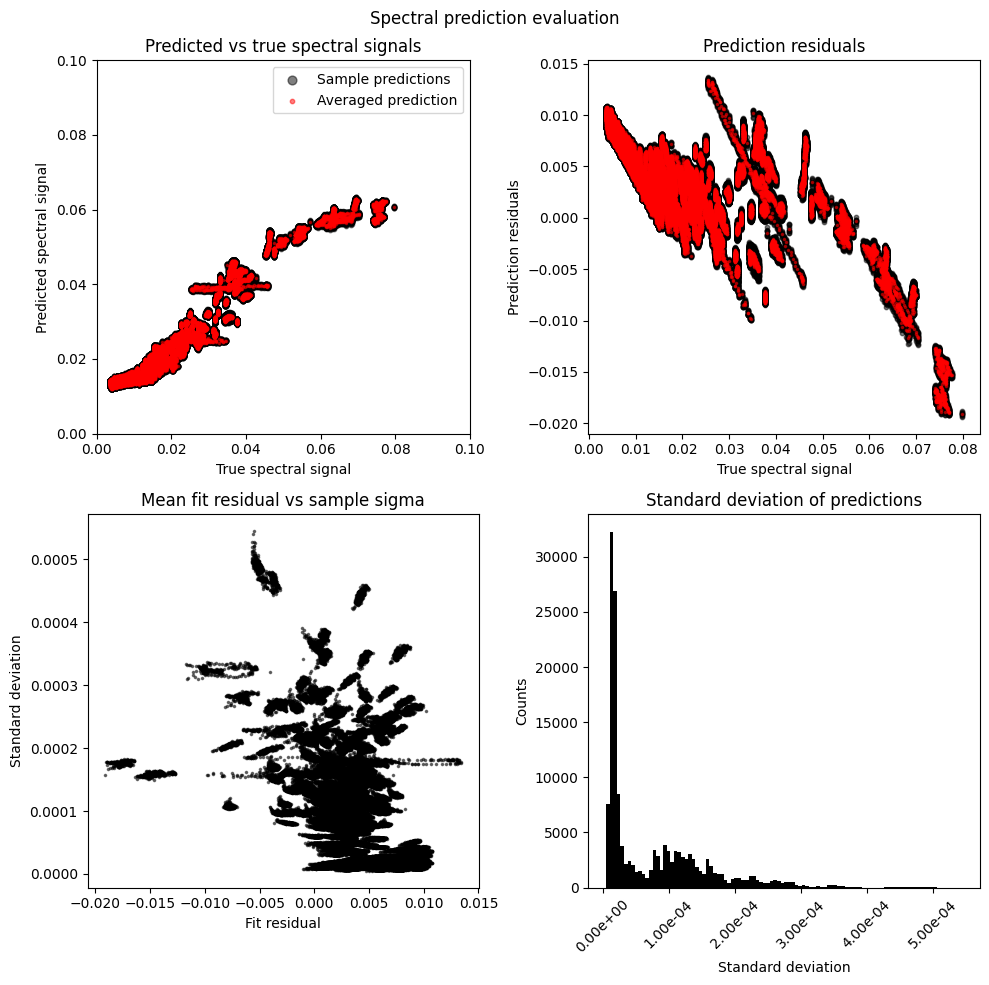

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
axs = axs.flatten()

fig.suptitle('Spectral prediction evaluation')

axs[0].set_title('Predicted vs true spectral signals')
axs[0].scatter(
    spectra.flatten(),
    spectrum_predictions.flatten(),
    s=10,
    alpha=0.5,
    color='black',
    label='Sample predictions'
)

axs[0].scatter(
    reference_spectra.flatten(),
    spectrum_predictions_avg.flatten(),
    s=2.5,
    alpha=0.5,
    color='red', 
    label='Averaged prediction'
)

axs[0].set_xlim(0,0.1)
axs[0].set_ylim(0,0.1)
axs[0].set_aspect('equal')
axs[0].set_xlabel('True spectral signal')
axs[0].set_ylabel('Predicted spectral signal')
axs[0].legend(loc='best', markerscale=2)

residuals = spectrum_predictions.flatten() - spectra.flatten()
avg_residual = spectrum_predictions_avg.flatten() - reference_spectra.flatten()

axs[1].set_title('Prediction residuals')
axs[1].scatter(
    spectra,
    residuals,
    s=10,
    alpha=0.5,
    color='black',
    label='Sample predictions'
)

axs[1].scatter(
    reference_spectra,
    avg_residual,
    s=2.5,
    alpha=0.5,
    color='red',
    label='Averaged prediction'
)

axs[1].set_xlabel('True spectral signal')
axs[1].set_ylabel('Prediction residuals')

axs[2].set_title('Mean fit residual vs sample sigma')
axs[2].scatter(avg_residual, spectrum_predictions_std.flatten(), color='black', alpha=0.5, s=2.5)
axs[2].set_xlabel('Fit residual')
axs[2].set_ylabel('Standard deviation')

axs[3].set_title('Standard deviation of predictions')
axs[3].hist(spectrum_predictions_std.flatten(), bins=100, color='black')
axs[3].xaxis.set_major_formatter(FormatStrFormatter('%.2e'))
axs[3].tick_params(axis='x', labelrotation=45)
axs[3].set_xlabel('Standard deviation')
axs[3].set_ylabel('Counts')

fig.tight_layout()
fig.show()

Still seem to have that weird problem, where true vs predicted signal looks OK-ish - mostly kind of diagonal. But, for some reason the predictions seem like they are capped at 0.06, while the true range of the data is up to ~ 0.08.

That aside for the moment, I think the more pressing issue is that our standard deviations are way too tight. Even if our predictions are pretty good (which I doubt, but for the sake of argument..) setting the error too low will tank the score. The scoring function finds the probability that the true value was drawn from a gaussian with our mean and sigma, like this:

```python
scipy.stats.norm.logpdf(true_spectrum, loc=our_predictions, scale=our_errors)
```

Two approaches to do a better job with the errors come to mind:

1. Figure out a way to use the observed signal to get a wavelength & signal dependent error for the instrument
2. Scale the prediction ensemble error until it encompasses the true value

The first approach is probably the more scientifically correct way to attack the problem - but I'm going to go with option 2. Seems like the easiest way to get validated error values.